# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
!git clone https://github.com/ainasarfaraz343-a11y/flyrank-internship.git
%cd flyrank-internship

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)

df = pd.read_csv('data/raw/content_refresh_anonymized.csv')
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

Cloning into 'flyrank-internship'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 164 (delta 61), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (164/164), 1.89 MiB | 13.34 MiB/s, done.
Resolving deltas: 100% (61/61), done.
/content/flyrank-internship/flyrank-internship


## 1. Question

*The research question and the decision it supports.*

Using only signals knowable before the fact, staleness and visibility, can
we point content teams to pages actually worth reviewing for a refresh,
rather than relying on guesswork about which pages "feel" old?

This supports a recurring, practical decision: with limited editorial time,
which pages should a team look at first? The output is a ranked queue with
reasons attached, not an automated verdict — a human still decides what
happens next.

In [9]:
# Qualitative section: no computation needed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Dataset:** FlyRank's starter release — `data/raw/content_refresh_anonymized.csv`,
30,000 content pages across 32 pseudonymized clients, trailing-90-day GSC/GA4
metrics per page.

**Excluded, and why:**
- `trend_direction`, `trend_pct` — these define the label; using them as
  features would leak the answer into the input.
- `content_id`, `client_id` — pseudonyms, used only for grouping/splitting.
- `avg_position == 0` rows (1,205) — means "no position data," not rank zero.

No client names, domains, or real queries appear anywhere in this project.

In [10]:
print(f"Total rows: {len(df)}")
print(f"Distinct clients: {df['client_id'].nunique()}")
print(f"Rows with avg_position == 0 (excluded from modeling): {(df['avg_position']==0).sum()}")

Total rows: 30000
Distinct clients: 32
Rows with avg_position == 0 (excluded from modeling): 1205


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Baseline:** `is_stale (days_since_last_update >= 90) × has_volume
(impressions_90d >= 300) × impressions_90d` — a transparent, readable score,
no fitted weights. Built after checking both signals against decline rate
individually; both came back MIXED (real pattern in the dense middle of the
data, weaker at sparse tails) — a disclosed finding, not a hidden weakness.

**Model:** Logistic Regression — binary target, interpretable coefficients,
a natural step up from a hand-written rule.

**Features:** staleness, impressions, clicks, CTR, position, engagement
rate, word count, search volume, content age, plus `has_word_count`,
`has_search_volume`, `has_engagement_rate` (missingness flags — missingness
here tracks content_type, so it's informative rather than random).

**Label:** `is_declining` = 1 when `trend_direction == 'down'`.

**Validation design:** Client-grouped 80/20 split (GroupShuffleSplit,
seed=42) instead of a random split — rows from the same client share hidden
patterns, and a random split lets a model partially memorize a client it's
already seen. Measured directly: 0.623 ROC-AUC (random) vs 0.559 (grouped) —
the gap is the honest cost of doing this right.

**Leakage check:** Deliberately injected `trend_pct` as a feature to test
the harness — AUC jumped to a perfect 1.000, confirming the setup catches
leakage when present. The real model excludes this column.

In [11]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

feature_cols = ['days_since_last_update', 'impressions_90d', 'clicks_90d',
                 'ctr', 'avg_position', 'engagement_rate', 'word_count',
                 'search_volume', 'content_age_days']

model_df = df[df['avg_position'] > 0].copy()
for col in ['word_count', 'search_volume', 'engagement_rate']:
    model_df[f'has_{col}'] = model_df[col].notna().astype(int)
    model_df[col] = model_df[col].fillna(0)
feature_cols = feature_cols + ['has_word_count', 'has_search_volume', 'has_engagement_rate']

X = model_df[feature_cols]
y = model_df['is_declining']
groups = model_df['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)
model_scores = clf.predict_proba(X_test_s)[:, 1]
model_auc = roc_auc_score(y_test, model_scores)
print(f"Model ROC-AUC (grouped split): {model_auc:.3f}")

Model ROC-AUC (grouped split): 0.559


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| Method | precision@50 | ROC-AUC |
|---|---|---|
| Rule baseline | 0.28 | — |
| Logistic Regression | 0.44 | 0.559 |

Base rate (majority class): 0.540.

The model beats the rule at the top of the ranking, but overall
discrimination (ROC-AUC ≈ 0.56) stays close to chance — both facts are
reported together rather than leading with only the flattering one.

In [12]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

test_full = model_df.iloc[test_idx].copy()
test_full['is_stale'] = (test_full['days_since_last_update'] >= 90).astype(int)
test_full['has_volume'] = (test_full['impressions_90d'] >= 300).astype(int)
baseline_scores = test_full['is_stale'] * test_full['has_volume'] * test_full['impressions_90d']

k = 50
base_rate = y_test.mean()
model_p50 = precision_at_k(model_scores, y_test.values, k)
baseline_p50 = precision_at_k(baseline_scores.values, y_test.values, k)

results = pd.DataFrame({
    'method': ['Rule baseline', 'Logistic Regression'],
    f'precision@{k}': [round(baseline_p50,3), round(model_p50,3)],
    'ROC-AUC': [np.nan, round(model_auc,3)]
})
print(f"Base rate: {base_rate:.3f}")
print(results)

Base rate: 0.540
                method  precision@50  ROC-AUC
0        Rule baseline          0.28      NaN
1  Logistic Regression          0.44    0.559


## 5. Limitations

*What this work cannot claim.*

Observational study on one 90-day snapshot — no claim that refreshing a page
*causes* recovery, only that some pages look worth reviewing first. Model
discrimination is weak (ROC-AUC ≈ 0.56); treat any single score as a
starting point, not a verdict. Not tested on clients or content types
outside this 30,000-page, 32-client dataset — the random-vs-grouped split
gap shows performance drops on a genuinely unseen client. Some flags likely
reflect data artifacts (e.g. zero CTR from a tracking issue) rather than a
real content problem, which is why every flag goes through human review
before any action.

In [13]:
# Qualitative section — no computation needed.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

7,234 of 30,000 pages are flagged `REVIEW_REFRESH`, each with a reason code
(`STALE_HIGH_VOLUME`, `STALE_LOW_VOLUME`, `FRESH_NO_ACTION`). An editor works
the top of the queue down, checking title/metadata/content freshness before
acting — the tool orders the work, it doesn't do it. Pages already strong on
position and CTR that still got flagged are known weak picks (found in
manual top-10 review) and are lower priority despite their score. Pages with
zero clicks despite real impressions need a tracking check before a content
rewrite.

**Not to automate:** publishing changes from the score alone, treating the
score as a guarantee, or deprioritizing a page without a human confirming
the reason still holds.

In [14]:
df['is_stale'] = (df['days_since_last_update'] >= 90).astype(int)
df['has_volume'] = (df['impressions_90d'] >= 300).astype(int)
df['score'] = df['is_stale'] * df['has_volume'] * df['impressions_90d']

def reason_code(row):
    if row['is_stale'] and row['has_volume']:
        return 'STALE_HIGH_VOLUME'
    elif row['is_stale'] and not row['has_volume']:
        return 'STALE_LOW_VOLUME'
    else:
        return 'FRESH_NO_ACTION'

df['reason_code'] = df.apply(reason_code, axis=1)
df['action'] = df['reason_code'].apply(lambda r: 'REVIEW_REFRESH' if r == 'STALE_HIGH_VOLUME' else 'NO_ACTION')

print(df['action'].value_counts())
print(df['reason_code'].value_counts())

action
NO_ACTION         22766
REVIEW_REFRESH     7234
Name: count, dtype: int64
reason_code
FRESH_NO_ACTION      20655
STALE_HIGH_VOLUME     7234
STALE_LOW_VOLUME      2111
Name: count, dtype: int64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Two charts for the deployed page: model vs baseline (precision@50), and the
cost of an honest split (random vs grouped ROC-AUC).

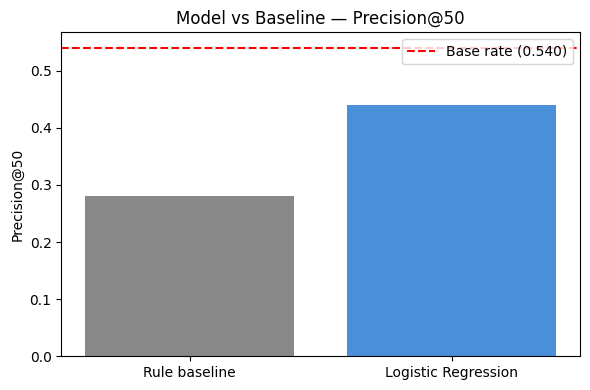

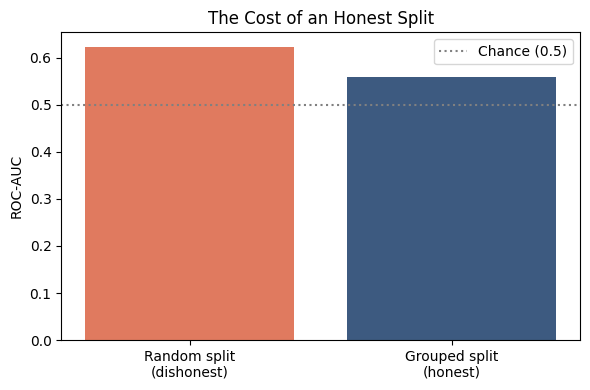

Charts saved to work/figures/, queue saved to work/outputs/


In [15]:
os.makedirs('work/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Rule baseline', 'Logistic Regression'], [0.28, 0.44], color=['#888', '#4a90d9'])
ax.axhline(y=0.540, color='red', linestyle='--', label='Base rate (0.540)')
ax.set_ylabel('Precision@50')
ax.set_title('Model vs Baseline — Precision@50')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/model_vs_baseline.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Random split\n(dishonest)', 'Grouped split\n(honest)'], [0.623, 0.559], color=['#e07a5f', '#3d5a80'])
ax.axhline(y=0.5, color='gray', linestyle=':', label='Chance (0.5)')
ax.set_ylabel('ROC-AUC')
ax.set_title('The Cost of an Honest Split')
ax.legend()
plt.tight_layout()
plt.savefig('work/figures/split_comparison.png', dpi=150)
plt.show()

os.makedirs('work/outputs', exist_ok=True)
df.sort_values('score', ascending=False).to_csv('work/outputs/baseline_action_score.csv', index=False)
print("Charts saved to work/figures/, queue saved to work/outputs/")

## 8. Demo outline + shareable cuts (ML-12)

### 5-minute demo outline

1. **Question (30 sec):** With thousands of pages and no time to review them
   all, which ones should a content team look at first for a possible
   refresh?

2. **Method (1 min):** Built a transparent rule first (staleness +
   visibility), then a Logistic Regression model — tested both under a
   client-grouped split so the model can't cheat by memorizing a client it's
   already seen.

3. **One chart (1 min):** *[show `model_vs_baseline.png`]* — the model beats
   the rule at the top of the ranking (precision@50: 0.44 vs 0.28), against
   a base rate of 0.540.

4. **One honest result (1.5 min):** The model's overall discrimination
   (ROC-AUC ≈ 0.56) is weak — close to chance. It's a better sorting tool at
   the top of the list, not a reliable classifier across the whole
   portfolio. Also show the random-vs-grouped split chart — the honest split
   costs 6 points of AUC, and that's the number worth trusting.

5. **One recommendation (1 min):** 7,234 of 30,000 pages are flagged for
   review, each with a reason code. An editor works the queue top-down,
   checking each flag by hand before acting — this is decision-support, not
   an automated system.

### Shareable cut — social post

Spent the last few weeks building a small, honest ML pipeline on real
content-performance data: a transparent rule baseline → a validated
Logistic Regression model → and an audit that deliberately broke my own
model to check for leakage before trusting any number.

Biggest lesson: switching from a random train/test split to a
client-grouped one dropped my model's score by 6 points — and that drop was
the *right* number, not a failure. The flattering number was the dishonest
one.

Full write-up (with the honest limitations, not just the wins): [paper link]

### Shareable cut — employer-facing summary

I built and validated a content-refresh prioritization model on a
30,000-page, 32-client real-world search dataset, comparing a transparent
rule baseline against a Logistic Regression model under a client-grouped
validation split. The model showed a measurable, honest improvement over
the baseline at the top of the ranking (precision@50: 0.44 vs. 0.28) while
I explicitly tested for and reported its limitations, including a
deliberate leakage audit and a documented gap between random and grouped
validation splits. The result is a working, reason-coded action playbook —
not just a model score — designed for a human reviewer to act on with full
visibility into its confidence and limits.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
